In this project, we will simulate a perfectly fair coin toss using a quantum computer. While a classical computer uses deterministic algorithms to fake a coin toss (pseudo-randomness), a quantum coin toss utilizes a qubit in a state of superposition to achieve a mathematically true 50/50 probability. We will map these quantum states to classical "Heads" and "Tails" outcomes.

<h2>Task 0: Environment & Circuit Prep</h2>
Set up your workspace and initialize the fundamental components.

[ ] Open your Jupyter Notebook and import the necessary Qiskit modules.

[ ] Create a quantum circuit with 1 qubit and 1 classical bit.

[ ] Output: A clean, error-free notebook ready for quantum instructions.

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

Multiple QuantumRegister and ClassicalRegister objects can be combined to create a circuit. Every QuantumRegister and ClassicalRegister can also be named.

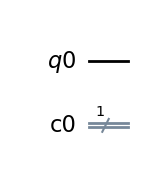

In [2]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)

circuit = QuantumCircuit(qr,cr)
circuit.draw("mpl")

Task 1: The Quantum Toss

Put the "coin" in the air.

[ ] Apply a Hadamard gate to your qubit to place it in an equal superposition of ∣0⟩ and ∣1⟩.

[ ] Add a measurement instruction to collapse the state and record the outcome on the classical bit.

[ ] Output: circuit.draw() displays a circuit with an H-gate followed by a measurement block.

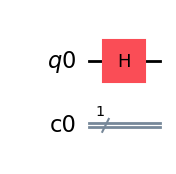

In [3]:
circuit.h(0)
circuit.draw("mpl")

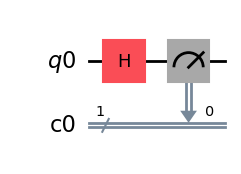

In [23]:
circuit.measure(0,0)
circuit.draw("mpl")

Task 2: Mapping the Outcome (The Game Logic)

Translate the quantum binary result into a human-readable coin toss.

[ ] Write a Python function that executes the circuit for exactly 1 shot.

[ ] Extract the result string (either '0' or '1').

[ ] Write an if/else statement that prints "Heads" if the result is '0', and "Tails" if the result is '1'.

[ ] Output: Running your Python function prints either "Heads" or "Tails" to the console.

In [ ]:

def toss(shots):
    sim_object = AerSimulator()
    result = sim_object.run(circuit, shots=shots, memory=True,meas_level=2).result()
    x = result.get_memory(circuit)
    print(x)
    if x == "0":
        return "Heads"
    else:
        return "Tails"



In [30]:
toss(shots=1)

['0']


'Tails'

Task 3: The Law of Large Numbers (Multiple Trials)

Prove that your quantum coin is perfectly fair.
[ ] Modify your code (or write a new cell) to run the circuit for 1,000 shots.

[ ] Extract the counts for '0' and '1'.

[ ] Output: Print the total number of Heads and Tails. You should see a nearly perfect 500/500 split, demonstrating true quantum probability.

[ ] Output (Bonus): Use Qiskit's plot_histogram to visualize this distribution.

In [45]:
def toss(shots):
    sim_object = AerSimulator(method="automatic")
    result = sim_object.run(circuit, shots=shots, memory=True, meas_level=2).result()
    counts = result.get_counts(circuit)

    # Map output to custom labels like 0:Heads, 1 : Tails in histogram
    renamed_counts = {}
    for key, value in counts.items():
        if key == '0':
            renamed_counts['Heads'] = value
        else:
            renamed_counts['Tails'] = value
    return plot_histogram([renamed_counts], title='Quantum Coin Simulation', legend=['automatic'])

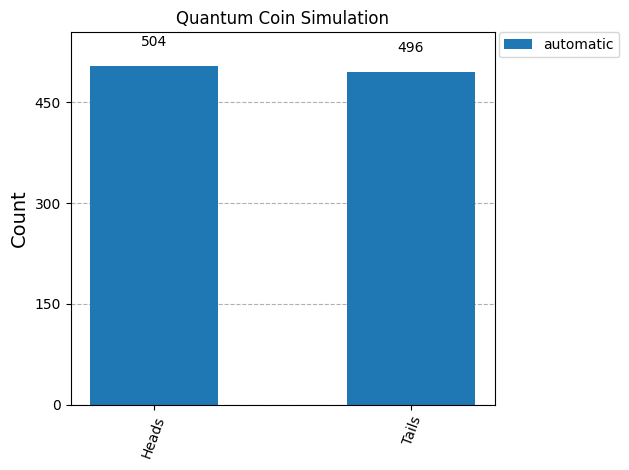

In [46]:
toss(shots=1000)

## ❌ Error
**QiskitError:**  
`No memory for experiment "<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000015FC8596200>". Please verify that you either ran a measurement level 2 job with the memory flag set, eg., "memory=True", or a measurement level 0/1 job.`

---

## ✅ Solution
Add `meas_level=2` when running the simulator.

---

## 🔎 Reason

### ⚡ Measurement levels in Qiskit Aer

- **Level 0 (raw data)**  
  Returns the raw signal from the hardware (like digitized waveforms).  
  Not useful unless you’re doing hardware calibration or signal processing.

- **Level 1 (IQ data)**  
  Returns processed complex values (in‑phase and quadrature components).  
  Still pretty low‑level, used for calibration and advanced readout analysis.

- **Level 2 (classical counts/memory)**  
  Returns the familiar bitstrings (`'0'`, `'1'`, `'01'`, etc.) that most people expect.  
  This is the level you need for `get_counts()` and `get_memory()`.
